In [1]:
import pandas as pd

In [2]:
csv = pd.read_csv('./reports/report.csv')
df = pd.DataFrame(csv)


In [3]:
df.head()

,Unnamed: 0,Autoencoder,State Detector,Health Assessment,Hybrid,Classic,True
0,0,Not Fall,Fall,Controlled Fall,Hard Fall,Hard Fall,Controlled Fall
1,1,Not Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
2,2,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
3,3,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
4,4,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall


In [4]:
df.tail()

,Unnamed: 0,Autoencoder,State Detector,Health Assessment,Hybrid,Classic,True
1195,1195,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
1196,1196,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
1197,1197,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
1198,1198,Not Fall,Fall,SlipTrip,SlipTrip,SlipTrip,Not Fall
1199,1199,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall


In [5]:
df

,Unnamed: 0,Autoencoder,State Detector,Health Assessment,Hybrid,Classic,True
0,0,Not Fall,Fall,Controlled Fall,Hard Fall,Hard Fall,Controlled Fall
1,1,Not Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
2,2,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
3,3,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
4,4,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
...,...,...,...,...,...,...,...
1195,1195,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
1196,1196,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
1197,1197,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
1198,1198,Not Fall,Fall,SlipTrip,SlipTrip,SlipTrip,Not Fall


In [6]:
df[(df["Autoencoder"] == "Fall") & (df["True"] != "Not Fall")].count()

Unnamed: 0           411
Autoencoder          411
State Detector       411
Health Assessment    411
Hybrid               411
Classic              411
True                 411
dtype: int64

In [7]:
df[(df["Autoencoder"] == "Fall") & (df["True"] == "Not Fall")].count()


Unnamed: 0           126
Autoencoder          126
State Detector       126
Health Assessment    126
Hybrid               126
Classic              126
True                 126
dtype: int64

In [8]:
df[(df["Autoencoder"] == "Not Fall") & (df["True"] != "Not Fall")].count()

Unnamed: 0           189
Autoencoder          189
State Detector       189
Health Assessment    189
Hybrid               189
Classic              189
True                 189
dtype: int64

In [9]:
df[(df["State Detector"] == "Fall") & (df["True"] == "Not Fall")].count()

Unnamed: 0           5
Autoencoder          5
State Detector       5
Health Assessment    5
Hybrid               5
Classic              5
True                 5
dtype: int64

In [10]:
df[(df["State Detector"] == "Not Fall") & (df["True"] != "Not Fall")].count()

Unnamed: 0           0
Autoencoder          0
State Detector       0
Health Assessment    0
Hybrid               0
Classic              0
True                 0
dtype: int64

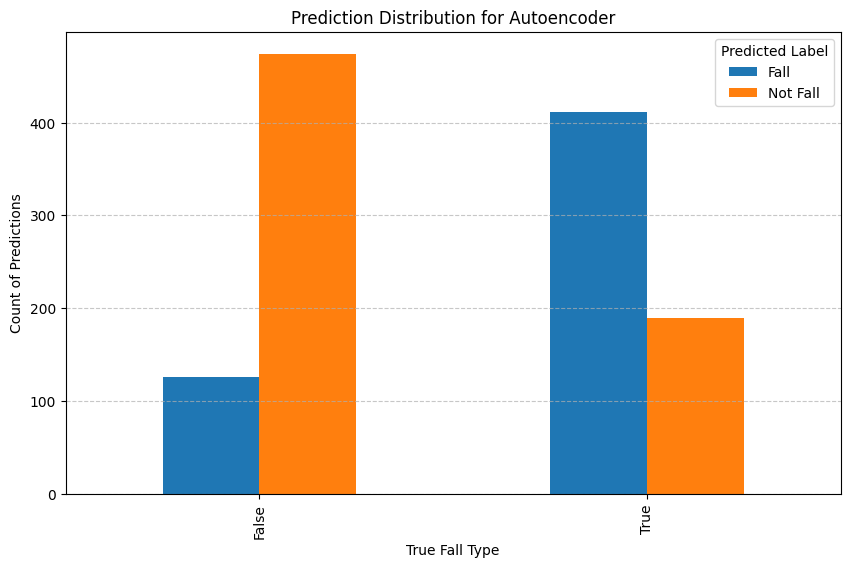

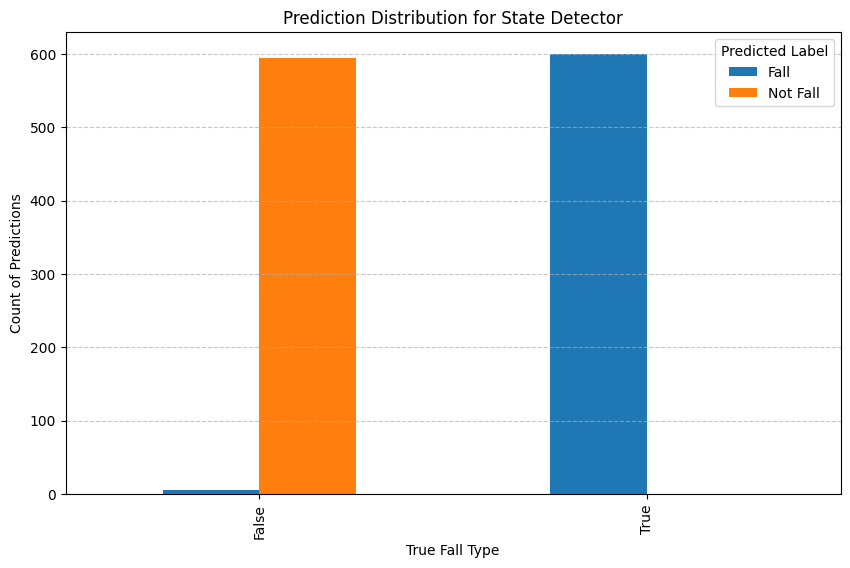

In [13]:
import matplotlib.pyplot as plt

models = ["Autoencoder", "State Detector"]

for model in models:
    counts = []
    labels = []

    # Build a table of how model predictions distribute for each true label
    pivot = pd.crosstab(df["True"] != "Not Fall", df[model])

    # Plot
    pivot.plot(kind="bar", figsize=(10,6))
    plt.title(f"Prediction Distribution for {model}")
    plt.xlabel("True Fall Type")
    plt.ylabel("Count of Predictions")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Predicted Label")
    plt.show()

# Prepare to only keep the rows the the state and autoencoder was correct
- This will ensure that the other predicitons is predicting a fall, when there accutally was a fall

In [33]:
df = df[df["True"] != "Not Fall"]

### Find out if all cases where both the ae and the sd belived it was not fall even if it was

In [45]:
df[(df["Autoencoder"] == "Not Fall") & (df["State Detector"] == "Not Fall")]

,Unnamed: 0,Autoencoder,State Detector,Health Assessment,Hybrid,Classic,True


In [44]:
amount_of_fall = len(df)

In [34]:
df[(df["Health Assessment"] == "Hard Fall") & (df["True"] == "Hard Fall")]

,Unnamed: 0,Autoencoder,State Detector,Health Assessment,Hybrid,Classic,True
400,400,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
401,401,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
402,402,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
403,403,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
408,408,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
...,...,...,...,...,...,...,...
787,787,Not Fall,Fall,Hard Fall,SlipTrip,Hard Fall,Hard Fall
792,792,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
793,793,Not Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
794,794,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall


In [35]:
df[(df["Health Assessment"] == "SlipTrip") & (df["True"] == "SlipTrip")]


,Unnamed: 0,Autoencoder,State Detector,Health Assessment,Hybrid,Classic,True
800,800,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
801,801,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
802,802,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
803,803,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
809,809,Not Fall,Fall,SlipTrip,Hard Fall,SlipTrip,SlipTrip
...,...,...,...,...,...,...,...
1187,1187,Not Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
1192,1192,Not Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
1193,1193,Not Fall,Fall,SlipTrip,Hard Fall,SlipTrip,SlipTrip
1194,1194,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip


In [36]:
df[(df["Health Assessment"] == "Controlled Fall") & (df["True"] == "Controlled Fall")]


,Unnamed: 0,Autoencoder,State Detector,Health Assessment,Hybrid,Classic,True
0,0,Not Fall,Fall,Controlled Fall,Hard Fall,Hard Fall,Controlled Fall
1,1,Not Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
2,2,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
3,3,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
8,8,Not Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
...,...,...,...,...,...,...,...
387,387,Not Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
392,392,Not Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
393,393,Not Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
394,394,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall


In [37]:
df[(df["Health Assessment"] == "Hard Fall") & (df["True"] != "Hard Fall")].count()

Unnamed: 0           14
Autoencoder          14
State Detector       14
Health Assessment    14
Hybrid               14
Classic              14
True                 14
dtype: int64

In [38]:
df[(df["Health Assessment"] == "SlipTrip") & (df["True"] != "SlipTrip")].count()


Unnamed: 0           8
Autoencoder          8
State Detector       8
Health Assessment    8
Hybrid               8
Classic              8
True                 8
dtype: int64

In [40]:
df[(df["Health Assessment"] != df["True"])].count()

Unnamed: 0           25
Autoencoder          25
State Detector       25
Health Assessment    25
Hybrid               25
Classic              25
True                 25
dtype: int64

In [41]:
df[(df["Hybrid"] != df["True"])].count()


Unnamed: 0           27
Autoencoder          27
State Detector       27
Health Assessment    27
Hybrid               27
Classic              27
True                 27
dtype: int64

In [42]:
df[(df["Classic"] != df["True"])].count()


Unnamed: 0           31
Autoencoder          31
State Detector       31
Health Assessment    31
Hybrid               31
Classic              31
True                 31
dtype: int64

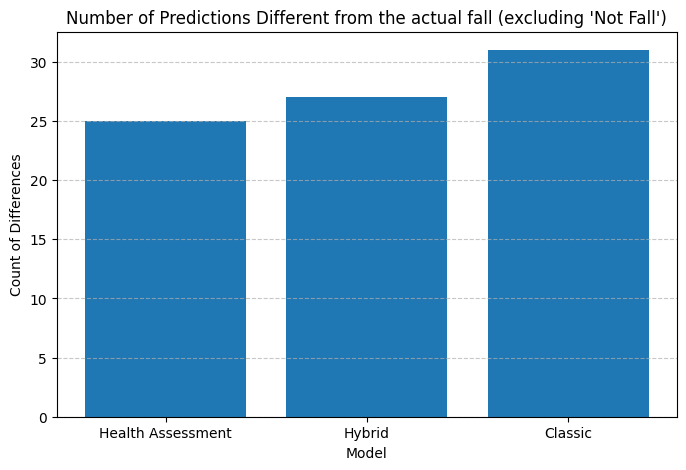

In [ ]:
comparison_columns = ["Health Assessment", "Hybrid", "Classic"]
differences = {col: (df[col] != df["True"]).sum() for col in comparison_columns}

# Convert to DataFrame for plotting
diff_df = pd.DataFrame(list(differences.items()), columns=["Model", "Differences"])

# Plot the results
plt.figure(figsize=(8, 5))
plt.bar(diff_df["Model"], diff_df["Differences"])
plt.title("Number of Predictions Different from the actual fall (excluding 'Not Fall')")
plt.xlabel("Model")
plt.ylabel("Count of Differences")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

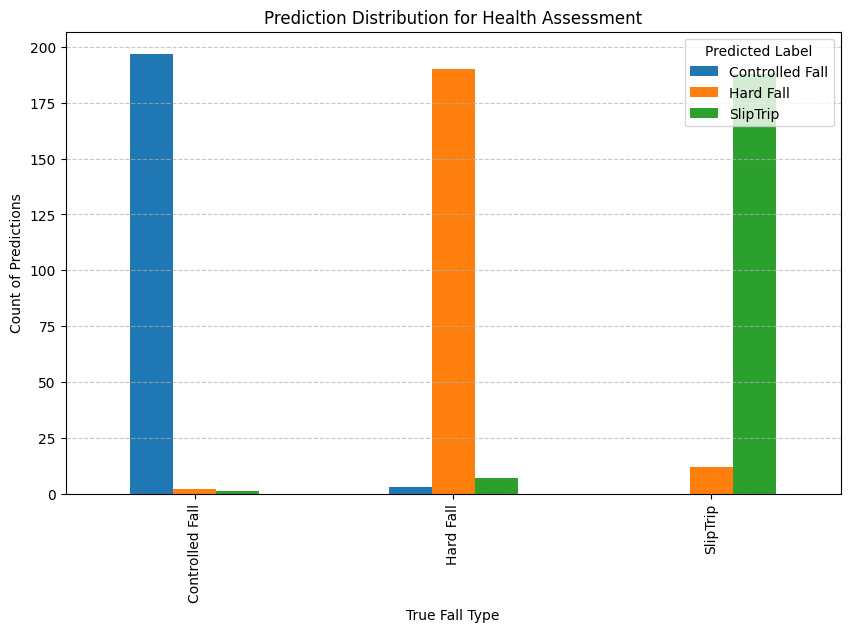

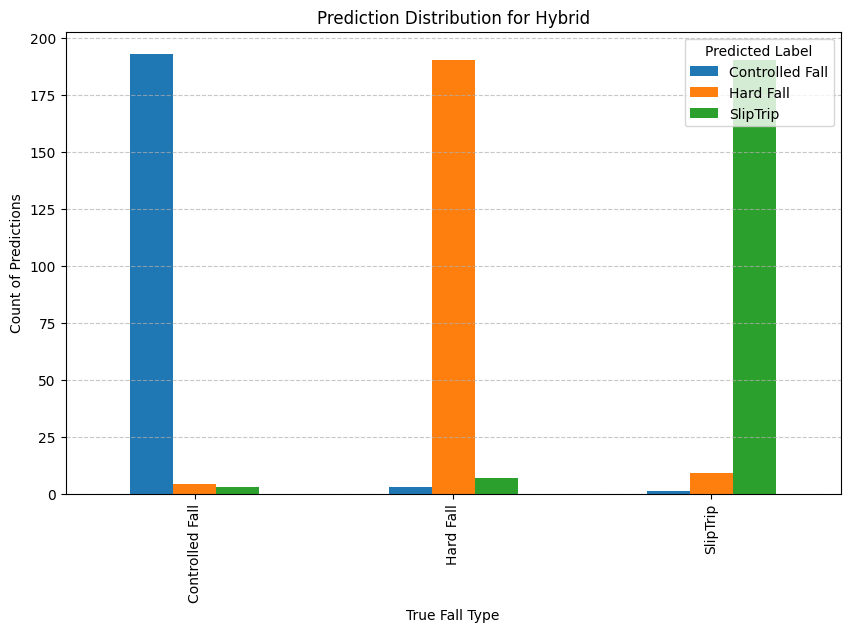

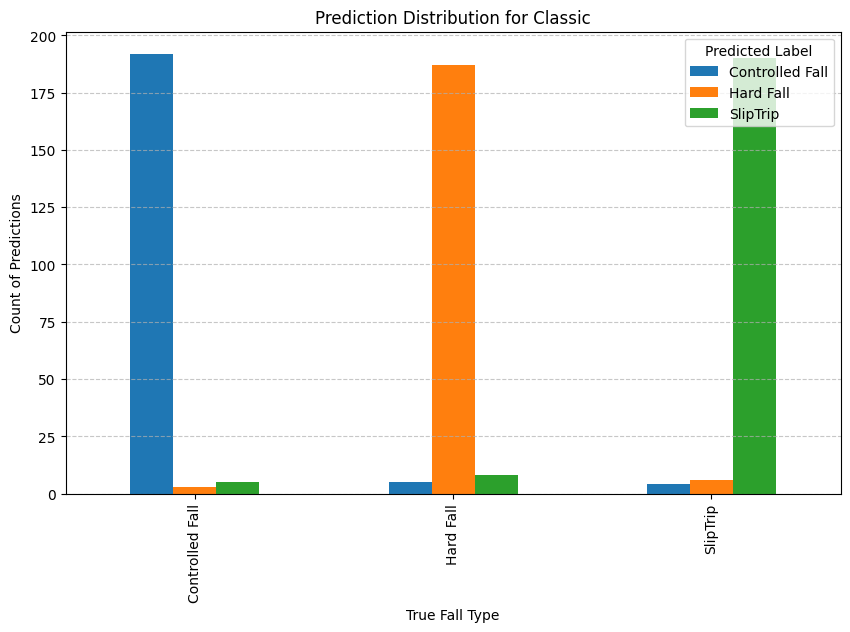

In [51]:
models = ["Health Assessment", "Hybrid", "Classic"]
true_classes = df["True"].unique()

# For each model, count predictions for each true class
for model in models:
    counts = []
    labels = []

    # Build a table of how model predictions distribute for each true label
    pivot = pd.crosstab(df["True"], df[model])

    # Plot
    pivot.plot(kind="bar", figsize=(10,6))
    plt.title(f"Prediction Distribution for {model}")
    plt.xlabel("True Fall Type")
    plt.ylabel("Count of Predictions")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Predicted Label")
    plt.show()